# 00 - Data Quality and Irregularities

This notebook documents how we discovered data irregularities before modeling Group 5 electricity consumption. It is intentionally more explanatory than the modeling notebooks: the goal is to show the checks, interpret the findings, and justify preprocessing choices.

We audit missing values, date parsing, duplicate keys, time continuity, weather join coverage, and target outliers. The final section applies a local demonstration fix under `tmp/data_quality_demo/`. The production version of the same logic lives in `src/group5_energy/pipeline.py`.

In [2]:
from pathlib import Path
import sys
import os

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / "tmp" / "matplotlib"))
sys.path.insert(0, str(ROOT / "src"))

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

RAW = ROOT / "data" / "00_raw"
CSV = ROOT / "data" / "02_processed" / "csv"
TMP_FIX = ROOT / "tmp" / "data_quality_demo"
TMP_FIX.mkdir(parents=True, exist_ok=True)

## 1. Files audited

The consumption files are already preprocessed by ACORN segment, but the model also depends on raw weather and holiday files. We audit all of them because irregularities in any joined source can affect features, validation, and forecasts.

In [3]:
files = {
    "half_hourly_history": CSV / "group_5_half_hourly.csv",
    "daily_history": CSV / "group_5_daily.csv",
    "half_hourly_forecast": CSV / "group_5_half_hourly_predict.csv",
    "daily_forecast": CSV / "group_5_daily_predict.csv",
    "weather_hourly_darksky": RAW / "weather_hourly_darksky.csv",
    "weather_daily_darksky": RAW / "weather_daily_darksky.csv",
    "temperatures_half_hour": RAW / "temperatures.csv",
    "uk_bank_holidays": RAW / "uk_bank_holidays.csv",
}

data = {
    name: pd.read_csv(path, sep=";", decimal=",") if name == "temperatures_half_hour" else pd.read_csv(path)
    for name, path in files.items()
}

pd.DataFrame([
    {
        "dataset": name,
        "rows": len(df),
        "columns": len(df.columns),
        "first_columns": ", ".join(df.columns[:8]) + ("..." if len(df.columns) > 8 else ""),
    }
    for name, df in data.items()
])

,dataset,rows,columns,first_columns
0,half_hourly_history,80796,6,"Acorn, Acorn_grouped, DateTime, nb_clients, Co..."
1,daily_history,1683,5,"Acorn, Date, nb_pts, nb_clients, Conso_kWh"
2,half_hourly_forecast,288,3,"Acorn, DateTime, Conso_moy_predict"
3,daily_forecast,96,3,"Acorn, Date, Conso_kWh_predict"
4,weather_hourly_darksky,21165,12,"visibility, windBearing, temperature, time, de..."
5,weather_daily_darksky,882,32,"temperatureMax, temperatureMaxTime, windBearin..."
6,temperatures_half_hour,39696,2,"DateTime, Temperature"
7,uk_bank_holidays,25,2,"Bank holidays, Type"


## 2. Missing values and parsing problems

First we check explicit missing values and timestamp parsing. A parsing failure would be critical because lag features and chronological validation both depend on correctly ordered timestamps.

**Finding:** consumption targets parse cleanly and have no missing values. Weather covariates have small gaps: hourly `pressure`, daily cloud/UV fields, and half-hourly temperature values.

In [4]:
missing_rows = []
for name, df in data.items():
    for col, missing in df.isna().sum().items():
        if missing:
            missing_rows.append({
                "dataset": name,
                "column": col,
                "missing_count": int(missing),
                "missing_rate": missing / len(df),
            })

pd.DataFrame(missing_rows).sort_values(["dataset", "missing_count"], ascending=[True, False])

,dataset,column,missing_count,missing_rate
4,temperatures_half_hour,Temperature,252,0.006348
1,weather_daily_darksky,cloudCover,1,0.001134
2,weather_daily_darksky,uvIndex,1,0.001134
3,weather_daily_darksky,uvIndexTime,1,0.001134
0,weather_hourly_darksky,pressure,13,0.000614


In [5]:
parse_specs = [
    ("half_hourly_history", "DateTime", None),
    ("daily_history", "Date", None),
    ("half_hourly_forecast", "DateTime", None),
    ("daily_forecast", "Date", None),
    ("weather_hourly_darksky", "time", None),
    ("weather_daily_darksky", "time", None),
    ("temperatures_half_hour", "DateTime", "mixed"),
    ("uk_bank_holidays", "Bank holidays", None),
]

parse_rows = []
for dataset_name, column, fmt in parse_specs:
    parsed = pd.to_datetime(data[dataset_name][column], format=fmt, errors="coerce")
    parse_rows.append({
        "dataset": dataset_name,
        "column": column,
        "parse_failures": int(parsed.isna().sum()),
        "min_timestamp": parsed.min(),
        "max_timestamp": parsed.max(),
    })

pd.DataFrame(parse_rows)

,dataset,column,parse_failures,min_timestamp,max_timestamp
0,half_hourly_history,DateTime,0,2012-06-30 22:00:00,2014-01-12 23:30:00
1,daily_history,Date,0,2012-07-01 00:00:00,2014-01-12 00:00:00
2,half_hourly_forecast,DateTime,0,2014-01-13 00:00:00,2014-01-14 23:30:00
3,daily_forecast,Date,0,2014-01-13 00:00:00,2014-02-13 00:00:00
4,weather_hourly_darksky,time,0,2011-11-01 00:00:00,2014-03-31 22:00:00
5,weather_daily_darksky,time,0,2011-11-01 00:00:00,2014-03-30 23:00:00
6,temperatures_half_hour,DateTime,0,2011-11-24 00:00:00,2014-02-27 23:30:00
7,uk_bank_holidays,Bank holidays,0,2012-02-01 00:00:00,2014-12-26 00:00:00


### Decision

We do not drop consumption rows for missing weather covariates. Weather is explanatory data, not the target. Dropping rows would damage the time series and make lag features less reliable. Instead, weather covariates are completed and interpolated before joins. The sklearn model pipeline still keeps imputers as a fallback.

## 3. Duplicate keys and time continuity

For modeling, each ACORN/timestamp pair must be unique. We also need continuous historical windows so previous-day and previous-week lag features are meaningful.

The main new irregularity is in daily weather, since raw `time` values are unique, but normalizing them to calendar dates creates duplicate dates on daylight-saving transition days.

In [6]:
def duplicate_count(df, keys):
    return int(df.duplicated(keys).sum())

weather_daily = data["weather_daily_darksky"].copy()
weather_daily["WeatherTime"] = pd.to_datetime(weather_daily["time"])
weather_daily["Date"] = weather_daily["WeatherTime"].dt.normalize()

duplicate_summary = pd.DataFrame([
    {"dataset": "half_hourly_history", "key": "Acorn + DateTime", "duplicates": duplicate_count(data["half_hourly_history"], ["Acorn", "DateTime"])},
    {"dataset": "daily_history", "key": "Acorn + Date", "duplicates": duplicate_count(data["daily_history"], ["Acorn", "Date"])},
    {"dataset": "weather_hourly_darksky", "key": "time", "duplicates": duplicate_count(data["weather_hourly_darksky"], ["time"])},
    {"dataset": "temperatures_half_hour", "key": "DateTime", "duplicates": duplicate_count(data["temperatures_half_hour"], ["DateTime"])},
    {"dataset": "weather_daily_darksky", "key": "raw time", "duplicates": duplicate_count(weather_daily, ["time"])},
    {"dataset": "weather_daily_darksky", "key": "normalized Date", "duplicates": duplicate_count(weather_daily, ["Date"])},
])

duplicate_summary

,dataset,key,duplicates
0,half_hourly_history,Acorn + DateTime,0
1,daily_history,Acorn + Date,0
2,weather_hourly_darksky,time,0
3,temperatures_half_hour,DateTime,0
4,weather_daily_darksky,raw time,0
5,weather_daily_darksky,normalized Date,3


In [7]:
weather_daily_duplicates = weather_daily[weather_daily.duplicated("Date", keep=False)].sort_values(["Date", "WeatherTime"])
weather_daily_duplicates[["Date", "time", "temperatureMax", "temperatureMin", "summary"]]

,Date,time,temperatureMax,temperatureMin,summary
376,2012-03-25,2012-03-25 00:00:00,13.79,4.40,Partly cloudy until evening.
85,2012-03-25,2012-03-25 23:00:00,18.18,3.84,Partly cloudy in the afternoon.
683,2013-03-31,2013-03-31 00:00:00,4.96,-1.54,Mostly cloudy until morning.
487,2013-03-31,2013-03-31 23:00:00,5.88,1.10,Mostly cloudy until evening.
830,2014-03-30,2014-03-30 00:00:00,19.82,8.53,"Mostly cloudy starting in the afternoon, conti..."
844,2014-03-30,2014-03-30 23:00:00,16.37,10.98,Mostly cloudy until evening.


### Exact weather grid gaps before fixing

After deterministic daily-weather deduplication, two calendar dates are absent from the daily weather grid. The hourly weather grid also has two missing hours. These are small gaps, but they matter because each gap is replicated across the three ACORN segments during feature joins.


In [8]:
daily_weather_one = weather_daily.sort_values("WeatherTime").drop_duplicates("Date", keep="first")
full_daily_weather_index = pd.date_range(daily_weather_one["Date"].min(), daily_weather_one["Date"].max(), freq="D")
missing_daily_weather_dates = full_daily_weather_index.difference(daily_weather_one["Date"])

hourly_weather_times = pd.to_datetime(data["weather_hourly_darksky"]["time"])
full_hourly_weather_index = pd.date_range(hourly_weather_times.min(), hourly_weather_times.max(), freq="h")
missing_hourly_weather_hours = full_hourly_weather_index.difference(hourly_weather_times)

pd.concat([
    pd.DataFrame({"issue": "missing daily weather date", "timestamp": missing_daily_weather_dates}),
    pd.DataFrame({"issue": "missing hourly weather hour", "timestamp": missing_hourly_weather_hours}),
], ignore_index=True)


,issue,timestamp
0,missing daily weather date,2012-10-28 00:00:00
1,missing daily weather date,2013-10-27 00:00:00
2,missing hourly weather hour,2013-09-09 23:00:00
3,missing hourly weather hour,2013-09-10 00:00:00


In [9]:
def continuity_report(df, group_col, time_col, expected_step):
    temp = df.copy()
    temp[time_col] = pd.to_datetime(temp[time_col])
    rows = []
    for group, values in temp.sort_values(time_col).groupby(group_col):
        timestamps = values[time_col].sort_values()
        gaps = timestamps.diff().dropna()
        bad_gaps = gaps[gaps != expected_step]
        expected_rows = int(((timestamps.max() - timestamps.min()) / expected_step) + 1)
        rows.append({
            group_col: group,
            "rows": len(values),
            "expected_rows_from_range": expected_rows,
            "bad_gap_count": len(bad_gaps),
            "min_timestamp": timestamps.min(),
            "max_timestamp": timestamps.max(),
        })
    return pd.DataFrame(rows)

half_continuity = continuity_report(data["half_hourly_history"], "Acorn", "DateTime", pd.Timedelta(minutes=30))
daily_continuity = continuity_report(data["daily_history"], "Acorn", "Date", pd.Timedelta(days=1))

half_continuity, daily_continuity

(     Acorn   rows  expected_rows_from_range  bad_gap_count  \
 0  ACORN-E  26932                     26932              0   
 1  ACORN-F  26932                     26932              0   
 2  ACORN-Q  26932                     26932              0   
 
         min_timestamp       max_timestamp  
 0 2012-06-30 22:00:00 2014-01-12 23:30:00  
 1 2012-06-30 22:00:00 2014-01-12 23:30:00  
 2 2012-06-30 22:00:00 2014-01-12 23:30:00  ,
      Acorn  rows  expected_rows_from_range  bad_gap_count min_timestamp  \
 0  ACORN-E   561                       561              0    2012-07-01   
 1  ACORN-F   561                       561              0    2012-07-01   
 2  ACORN-Q   561                       561              0    2012-07-01   
 
   max_timestamp  
 0    2014-01-12  
 1    2014-01-12  
 2    2014-01-12  )

### Decision

The consumption series is regular and has no duplicate ACORN timestamps, so we preserve all target rows. For daily weather duplicates, the pipeline now sorts by raw `WeatherTime` and keeps the earliest record for each normalized date. This rule is deterministic and prevents duplicate rows during feature joins.

## 4. Weather join coverage before fixing

This step joins raw weather to consumption timestamps. The purpose is to measure the practical impact of weather irregularities on the modeling frame.

Before cleaning, a few weather timestamps are missing, half-hourly temperatures contain null values, and raw daily weather can multiply rows because of duplicate normalized dates.

In [10]:
half = data["half_hourly_history"].copy()
half["DateTime"] = pd.to_datetime(half["DateTime"])
half["WeatherHour"] = half["DateTime"].dt.floor("h")

hourly_weather = data["weather_hourly_darksky"].copy()
hourly_weather["WeatherHour"] = pd.to_datetime(hourly_weather["time"])

temperatures = data["temperatures_half_hour"].copy()
temperatures["DateTime_parsed"] = pd.to_datetime(temperatures["DateTime"], format="mixed", errors="coerce")
temperatures["Temperature_num"] = pd.to_numeric(temperatures["Temperature"], errors="coerce")

half_join = (
    half[["Acorn", "DateTime", "WeatherHour"]]
    .merge(hourly_weather[["WeatherHour", "temperature", "pressure"]], on="WeatherHour", how="left")
    .merge(temperatures[["DateTime_parsed", "Temperature_num"]], left_on="DateTime", right_on="DateTime_parsed", how="left")
)

pd.DataFrame([
    {"check": "hourly weather temperature missing after join", "missing_rows": int(half_join["temperature"].isna().sum()), "missing_rate": half_join["temperature"].isna().mean()},
    {"check": "hourly weather pressure missing after join", "missing_rows": int(half_join["pressure"].isna().sum()), "missing_rate": half_join["pressure"].isna().mean()},
    {"check": "half-hour temperature missing after join", "missing_rows": int(half_join["Temperature_num"].isna().sum()), "missing_rate": half_join["Temperature_num"].isna().mean()},
])

,check,missing_rows,missing_rate
0,hourly weather temperature missing after join,12,0.000149
1,hourly weather pressure missing after join,72,0.000891
2,half-hour temperature missing after join,348,0.004307


In [11]:
daily = data["daily_history"].copy()
daily["Date"] = pd.to_datetime(daily["Date"]).dt.normalize()
weather_daily_raw = data["weather_daily_darksky"].copy()
weather_daily_raw["Date"] = pd.to_datetime(weather_daily_raw["time"]).dt.normalize()

raw_daily_join = daily[["Acorn", "Date"]].merge(
    weather_daily_raw[["Date", "temperatureMax", "cloudCover", "uvIndex"]], on="Date", how="left"
)

pd.DataFrame([
    {"check": "rows before daily weather join", "value": len(daily)},
    {"check": "rows after raw daily weather join", "value": len(raw_daily_join)},
    {"check": "daily temperatureMax missing rows", "value": int(raw_daily_join["temperatureMax"].isna().sum())},
    {"check": "daily cloudCover missing rows", "value": int(raw_daily_join["cloudCover"].isna().sum())},
    {"check": "daily uvIndex missing rows", "value": int(raw_daily_join["uvIndex"].isna().sum())},
])

,check,value
0,rows before daily weather join,1683
1,rows after raw daily weather join,1686
2,daily temperatureMax missing rows,6
3,daily cloudCover missing rows,9
4,daily uvIndex missing rows,9


### Decision

Weather gaps should be fixed in weather space, not by altering consumption. We complete weather time grids and interpolate numeric weather variables over time. This keeps every valid consumption observation available for modeling and avoids accidental duplicate rows after joins.

## 5. Local demo fix in `tmp/data_quality_demo`

The next cell applies the cleaning logic locally and writes demo files to `tmp/data_quality_demo/`. These files are not used by the pipeline, they are here to make the preprocessing choices transparent.

The production implementation now follows the same principles in `pipeline.py`: sort before deduplication, complete time grids, interpolate numeric weather covariates, fill categorical weather labels, and leave targets unchanged. The generated clean/intermediate files are written to `data/01_interim/group5` rather than overwriting client-provided files.

In [12]:
def complete_time_series_local(df, time_col, freq, numeric_cols, categorical_cols):
    fixed = df.copy()
    fixed[time_col] = pd.to_datetime(fixed[time_col])
    fixed = fixed.drop_duplicates(time_col).sort_values(time_col).set_index(time_col)
    full_index = pd.date_range(fixed.index.min(), fixed.index.max(), freq=freq, name=time_col)
    fixed = fixed.reindex(full_index)
    if numeric_cols:
        fixed[numeric_cols] = fixed[numeric_cols].interpolate(method="time").ffill().bfill()
    for col in categorical_cols:
        if col in fixed.columns:
            fixed[col] = fixed[col].ffill().bfill().fillna("missing")
    return fixed.reset_index()

# Hourly weather.
hourly_numeric = ["visibility", "windBearing", "temperature", "dewPoint", "pressure", "apparentTemperature", "windSpeed", "humidity"]
hourly_fixed = data["weather_hourly_darksky"].copy()
hourly_fixed["WeatherHour"] = pd.to_datetime(hourly_fixed["time"])
hourly_fixed = hourly_fixed.drop(columns=["time"])
for col in hourly_numeric:
    hourly_fixed[col] = pd.to_numeric(hourly_fixed[col], errors="coerce")
hourly_fixed = complete_time_series_local(hourly_fixed, "WeatherHour", "h", hourly_numeric, ["precipType", "icon", "summary"])

# Half-hour temperatures.
temp_fixed = data["temperatures_half_hour"].copy()
temp_fixed["DateTime"] = pd.to_datetime(temp_fixed["DateTime"], format="mixed", errors="coerce")
temp_fixed = temp_fixed.rename(columns={"Temperature": "temperature_half_hour"})
temp_fixed["temperature_half_hour"] = pd.to_numeric(temp_fixed["temperature_half_hour"], errors="coerce")
temp_fixed = complete_time_series_local(temp_fixed, "DateTime", "30min", ["temperature_half_hour"], [])

# Daily weather.
daily_weather_fixed = data["weather_daily_darksky"].copy()
daily_weather_fixed["WeatherTime"] = pd.to_datetime(daily_weather_fixed["time"])
daily_weather_fixed["Date"] = daily_weather_fixed["WeatherTime"].dt.normalize()
daily_weather_fixed = daily_weather_fixed.sort_values("WeatherTime").drop_duplicates("Date", keep="first")
daily_numeric = [
    "temperatureMax", "dewPoint", "cloudCover", "windSpeed", "pressure", "visibility", "humidity",
    "apparentTemperatureHigh", "apparentTemperatureLow", "apparentTemperatureMax", "temperatureLow",
    "temperatureMin", "temperatureHigh", "uvIndex", "apparentTemperatureMin", "moonPhase",
]
for col in daily_numeric:
    daily_weather_fixed[col] = pd.to_numeric(daily_weather_fixed[col], errors="coerce")
daily_weather_fixed["temperatureMean"] = daily_weather_fixed[["temperatureMin", "temperatureMax"]].mean(axis=1)
daily_weather_fixed["temperatureRange"] = daily_weather_fixed["temperatureMax"] - daily_weather_fixed["temperatureMin"]
daily_numeric = daily_numeric + ["temperatureMean", "temperatureRange"]
daily_weather_fixed = complete_time_series_local(daily_weather_fixed, "Date", "D", daily_numeric, ["icon", "precipType", "summary"])

hourly_fixed.to_csv(TMP_FIX / "weather_hourly_fixed_demo.csv", index=False)
temp_fixed.to_csv(TMP_FIX / "temperatures_fixed_demo.csv", index=False)
daily_weather_fixed.to_csv(TMP_FIX / "weather_daily_fixed_demo.csv", index=False)

pd.DataFrame([
    {"fixed_dataset": "hourly_weather", "rows": len(hourly_fixed), "missing_cells": int(hourly_fixed.isna().sum().sum()), "duplicate_times": int(hourly_fixed.duplicated("WeatherHour").sum())},
    {"fixed_dataset": "half_hour_temperatures", "rows": len(temp_fixed), "missing_cells": int(temp_fixed.isna().sum().sum()), "duplicate_times": int(temp_fixed.duplicated("DateTime").sum())},
    {"fixed_dataset": "daily_weather", "rows": len(daily_weather_fixed), "missing_cells": int(daily_weather_fixed.isna().sum().sum()), "duplicate_times": int(daily_weather_fixed.duplicated("Date").sum())},
])

,fixed_dataset,rows,missing_cells,duplicate_times
0,hourly_weather,21167,0,0
1,half_hour_temperatures,39696,0,0
2,daily_weather,881,29,0


In [13]:
half_join_fixed = (
    half[["Acorn", "DateTime", "WeatherHour"]]
    .merge(hourly_fixed[["WeatherHour", "temperature", "pressure"]], on="WeatherHour", how="left")
    .merge(temp_fixed[["DateTime", "temperature_half_hour"]], on="DateTime", how="left")
)

daily_join_fixed = daily[["Acorn", "Date"]].merge(
    daily_weather_fixed[["Date", "temperatureMax", "cloudCover", "uvIndex"]], on="Date", how="left"
)

pd.DataFrame([
    {"check": "fixed hourly temperature missing after join", "missing_rows": int(half_join_fixed["temperature"].isna().sum())},
    {"check": "fixed hourly pressure missing after join", "missing_rows": int(half_join_fixed["pressure"].isna().sum())},
    {"check": "fixed half-hour temperature missing after join", "missing_rows": int(half_join_fixed["temperature_half_hour"].isna().sum())},
    {"check": "fixed daily temperatureMax missing after join", "missing_rows": int(daily_join_fixed["temperatureMax"].isna().sum())},
    {"check": "fixed daily cloudCover missing after join", "missing_rows": int(daily_join_fixed["cloudCover"].isna().sum())},
    {"check": "fixed daily uvIndex missing after join", "missing_rows": int(daily_join_fixed["uvIndex"].isna().sum())},
])

,check,missing_rows
0,fixed hourly temperature missing after join,0
1,fixed hourly pressure missing after join,0
2,fixed half-hour temperature missing after join,0
3,fixed daily temperatureMax missing after join,0
4,fixed daily cloudCover missing after join,0
5,fixed daily uvIndex missing after join,0


## 6. Target outliers

Target outliers require judgment. A simple IQR rule flags unusually high consumption, but those points are plausible: cold periods increase daily electricity demand, and evening half-hourly peaks are normal household behavior.

We therefore treat outliers as diagnostic information, not as errors to delete.

In [14]:
def iqr_outlier_summary(df, target):
    rows = []
    for acorn, group in df.groupby("Acorn"):
        x = pd.to_numeric(group[target], errors="coerce")
        q1, q3 = x.quantile([0.25, 0.75])
        iqr = q3 - q1
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        mask = (x < low) | (x > high)
        rows.append({
            "Acorn": acorn,
            "target": target,
            "lower_bound": low,
            "upper_bound": high,
            "outlier_count": int(mask.sum()),
            "outlier_rate": mask.mean(),
            "min_value": x.min(),
            "max_value": x.max(),
        })
    return pd.DataFrame(rows)

pd.concat([
    iqr_outlier_summary(data["half_hourly_history"], "Conso_moy"),
    iqr_outlier_summary(data["daily_history"], "Conso_kWh"),
], ignore_index=True)

,Acorn,target,lower_bound,upper_bound,outlier_count,outlier_rate,min_value,max_value
0,ACORN-E,Conso_moy,0.010215,0.406293,510,0.018937,0.087896,0.500192
1,ACORN-F,Conso_moy,0.002167,0.371390,175,0.006498,0.083240,0.435725
2,ACORN-Q,Conso_moy,0.014840,0.291146,65,0.002413,0.071207,0.325279
3,ACORN-E,Conso_kWh,2.383857,17.870119,0,0.000000,7.087237,16.050467
4,ACORN-F,Conso_kWh,3.874842,14.386722,0,0.000000,7.146596,13.494601
5,ACORN-Q,Conso_kWh,4.251097,10.723424,0,0.000000,6.118373,10.350369


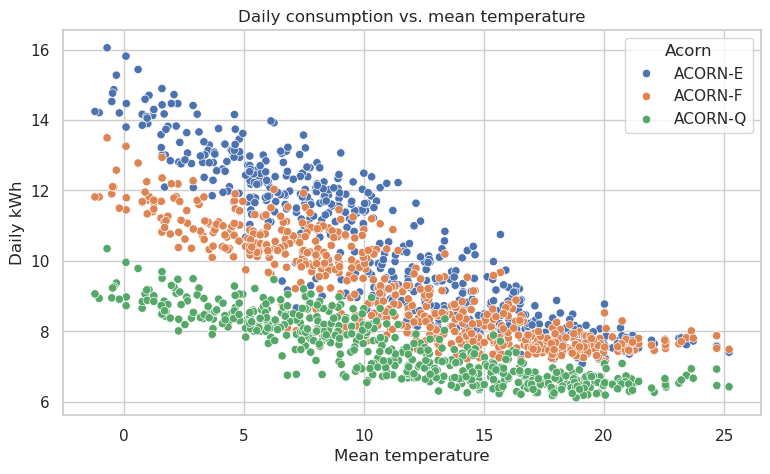

In [15]:
daily_with_weather = data["daily_history"].copy()
daily_with_weather["Date"] = pd.to_datetime(daily_with_weather["Date"]).dt.normalize()
daily_with_weather = daily_with_weather.merge(daily_weather_fixed[["Date", "temperatureMean"]], on="Date", how="left")

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=daily_with_weather, x="temperatureMean", y="Conso_kWh", hue="Acorn", ax=ax)
ax.set_title("Daily consumption vs. mean temperature")
ax.set_xlabel("Mean temperature")
ax.set_ylabel("Daily kWh")
plt.show()

### Decision

We keep target outliers. Removing high winter days or evening peaks would make the model underpredict exactly the periods where forecasting matters most. The model uses lag, rolling, calendar, and weather features to learn this behavior instead of censoring it.

## 7. Final preprocessing decisions

The final production choices are:

1. Keep all valid consumption target rows; do not interpolate or cap `Conso_moy` or `Conso_kWh`.
2. Resolve daily weather duplicates deterministically by sorting by raw `WeatherTime` and keeping the earliest record per date.
3. Complete hourly, half-hourly, and daily weather grids before joining to consumption.
4. Interpolate numeric weather covariates over time, because weather changes smoothly enough for short gaps.
5. Forward/backward fill coarse categorical weather labels such as `icon`, `summary`, and `precipType`.
6. Keep sklearn imputers in the model pipeline as a safety net for unexpected future missing covariates.
7. Preserve chronological validation so preprocessing does not leak future target values.

The local files under `tmp/data_quality_demo/` are illustrative only. The hard fix is in the Python pipeline, which writes cleaned/intermediate data to `data/01_interim/group5` and model-ready feature files to `data/02_processed/group5_modeling` without overwriting the original client files.